In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
# cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
# fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

# Select parent sources who have at least one significant emission line (>5 S/N ratio)

In [3]:
# FIT = FitSpectrum()

# ALL_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=None)
# ALL_SPECTRA = ALL_SPECTRA.subtype_filter(subtype='QSO', exclude=True)
# ALL_SPECTRA = ALL_SPECTRA.stack_data()
# ALL_SPECTRA = ALL_SPECTRA.shift_to_rest_frame()
# print('Total number of spectra:', len(ALL_SPECTRA.targetID))

In [4]:
# ALL_SPECTRA = FIT.label_emission_lines(ALL_SPECTRA, 5)
# ALL_SPECTRA = FIT.significant_emission_filter(ALL_SPECTRA)
# print('Total number of spectra:', len(ALL_SPECTRA.targetID))

In [5]:
# ALL_SPECTRA = ALL_SPECTRA.shrink_dataset(5)
# print('Number of spectra after shrinking:', len(ALL_SPECTRA.targetID))

In [6]:
DP = DP()
# dp_parent, model_1comp, left_2comp, right_2comp = DP.fit_all(data_class=ALL_SPECTRA, n_jobs=10)
# DP.get_catalog(df=dp_parent, fname='./catalogs/all_catalog.fits', model_1comp=model_1comp, left_2comp=left_2comp, right_2comp=right_2comp)


# dp_sample, model_1comp, left_2comp, right_2comp = DP.select_dp_sample(dp_parent, model_1comp, left_2comp, right_2comp)
# DP.get_catalog(df=dp_sample, fname='./catalogs/dp_catalog.fits', model_1comp=model_1comp, left_2comp=left_2comp, right_2comp=right_2comp)


In [7]:
dp_sample, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/dp_catalog.fits')
dp_sample.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,OII3729_rank,Hbeta_rank,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank,dp_count
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.451893,-78.319199,50.218773,30.572901,...,1,6,9,4,7,0,2,5,8,1
1,39627739380057506,177.058472,-1.984356,0.102379,10.324259,-0.880754,112.483803,-62.245144,42.930370,68.479820,...,4,2,9,8,3,0,1,5,7,1
2,39627739380058467,177.097977,-1.888290,0.123931,10.402426,1.031611,88.860611,-27.739218,29.598230,52.082478,...,1,4,9,7,8,0,2,5,6,1
3,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,80.845169,-86.188843,52.286289,59.410812,...,6,2,9,8,4,0,1,3,5,2
4,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,88.226196,-73.512642,38.063850,50.911797,...,2,4,9,8,6,0,1,5,7,3


OII3726: 1149
OII3729: 1999
Hbeta: 3885
OIII4959: 208
OIII5007: 1253
NII6548: 1652
Halpha: 17966
NII6583: 12104
SII6716: 4530
SII6731: 2423


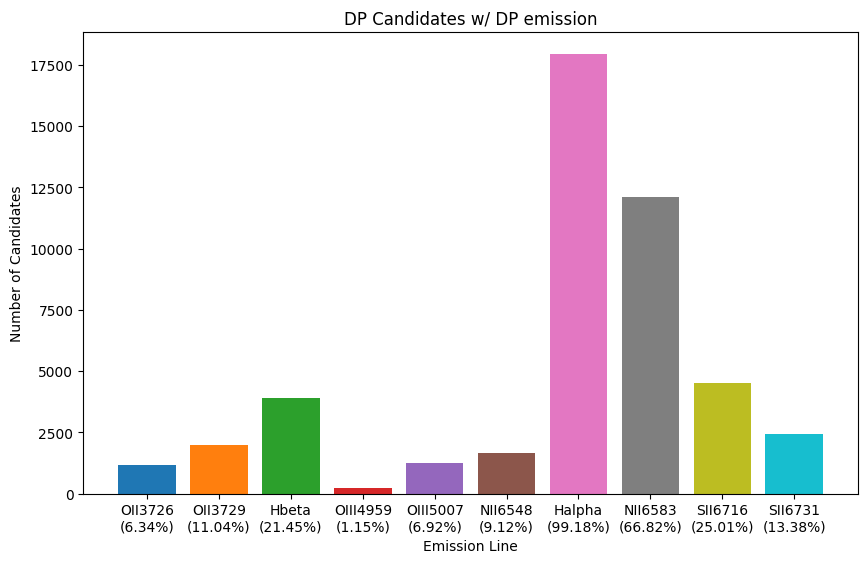

In [8]:
dp_cols = ['OII3726_dp', 'OII3729_dp',
            'Hbeta_dp',
            'OIII4959_dp', 'OIII5007_dp',
            'NII6548_dp', 'Halpha_dp', 'NII6583_dp', 
            'SII6716_dp', 'SII6731_dp']
plt.figure(figsize=(10, 6))
for col in dp_cols:
    dp_sample[col] = dp_sample[col].fillna(False)
    print(f"{col[:-3]}: {np.sum(dp_sample[col])}")
    plt.bar(col[:-3]+f'\n({np.sum(dp_sample[col]) / len(dp_sample):.2%})', np.sum(dp_sample[col]))
plt.xlabel("Emission Line")
plt.ylabel("Number of Candidates")
plt.title("DP Candidates w/ DP emission")
# plt.savefig("./figures/Jan2/dp_candidates_emission.png")
plt.show()

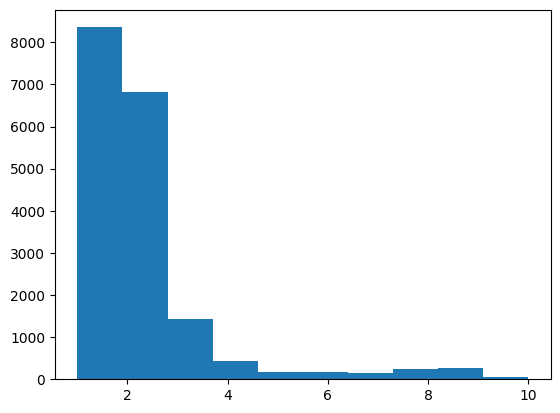

In [10]:
plt.hist(dp_sample['dp_count'])
# plt.yscale('log')
plt.show()